# **DATA PREPROCESSING**

---

## **1. Import libraries**

In [1]:
import sys, os
from pathlib import Path
import pandas as pd
import numpy as np  

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.visualization import plot_distribution_with_zoom
from src.data.preprocessing import (
    detect_outliers_iqr_summary,
    impute_categorical_mode,
    impute_tiki_data,
    impute_ebay_data,
    cap_outliers_percentile,
    engineer_tiki_features,
    engineer_ebay_features,
)

## **2. Load Raw Data**

Trong giai đoạn đầu của quá trình tiền xử lý, nhóm tiến hành tải tập dữ liệu thô (raw data) đã được thu thập từ E-commerce. Dữ liệu này được lưu trữ dưới định dạng tệp CSV nằm trong cấu trúc thư mục dự án (`data/raw`).

In [2]:
tiki_path = "../data/raw/products.csv"
df_tiki = pd.read_csv(tiki_path)

ebay_path = "../data/raw/ebay_products.csv"
df_ebay = pd.read_csv(ebay_path)

print(f"Tiki dataset shape: {df_tiki.shape}")
print(f"Ebay dataset shape: {df_ebay.shape}")

Tiki dataset shape: (10000, 11)
Ebay dataset shape: (15744, 31)


Dữ liệu được đọc từ tệp `products.csv` và `ebay_products.csv` và được khởi tạo dưới dạng cấu trúc bảng lưu vào biến DataFrame `df_tiki` và `df_ebay`.

## **3. Data Cleaning & Consistency Check**

Quá trình thu thập dữ liệu bằng Web Crawling hoặc gọi API thường không tránh khỏi việc thu thập phải các bản ghi trùng lặp hoặc bị lỗi cấu trúc trang dẫn đến các dòng trống. Do đó, bước làm sạch và kiểm tra tính nhất quán là cực kỳ quan trọng.

### **3.1. Handling Duplicates & Empty Rows**

Để đánh giá tính toàn vẹn dữ liệu, nhóm tiến hành kiểm tra các bản ghi trùng lặp trên toàn bộ tập dữ liệu bằng hàm `duplicated()` trong Pandas. 
* **Duplicate Rows:** Kiểm tra mọi hàng có nội dung hoàn toàn giống nhau trên tất cả các thuộc tính.
* **Empty Rows:** Phát hiện các dòng bị rỗng hoàn toàn (tất cả các cột đều là giá trị NaN).

In [3]:
# Check for duplicate rows in Tiki
duplicate_mask_tiki = df_tiki.duplicated(keep=False)
num_duplicate_rows_tiki = df_tiki.duplicated().sum()
print(f"Are there any duplicate rows in Tiki?: {duplicate_mask_tiki.any()}")
print(f"Total number of duplicate rows in Tiki: {num_duplicate_rows_tiki}")

# Check for duplicate rows in Ebay
duplicate_mask_ebay = df_ebay.duplicated(keep=False)
num_duplicate_rows_ebay = df_ebay.duplicated().sum()
print(f"Are there any duplicate rows in Ebay?: {duplicate_mask_ebay.any()}")
print(f"Total number of duplicate rows in Ebay: {num_duplicate_rows_ebay}")

Are there any duplicate rows in Tiki?: False
Total number of duplicate rows in Tiki: 0
Are there any duplicate rows in Ebay?: False
Total number of duplicate rows in Ebay: 0


In [4]:
# 2. Check for completely empty rows
num_empty_rows_tiki = df_tiki.isna().all(axis=1).sum()
print(f"Total number of completely empty rows in Tiki: {num_empty_rows_tiki}")

num_empty_rows_ebay = df_ebay.isna().all(axis=1).sum()
print(f"Total number of completely empty rows in Ebay: {num_empty_rows_ebay}")

df_tiki.dropna(how='all', inplace=True)
df_ebay.dropna(how='all', inplace=True)

Total number of completely empty rows in Tiki: 0
Total number of completely empty rows in Ebay: 0


Bộ dữ liệu không chứa dòng trùng lặp hay dòng rỗng hoàn toàn, cho thấy quá trình thu thập dữ liệu (Crawl/API) đã đảm bảo tốt tính toàn vẹn và duy nhất của các bản ghi. Dữ liệu hiện đã sẵn sàng để tiến hành kiểm tra chuyên sâu hơn (xử lý Missing Values và chuẩn hóa Data Types).

### **3.2. Data Type Conversion**

Ép kiểu dữ liệu cho chuẩn xác (ví dụ: chuyển cột ngày tháng sang `datetime`, cột giá tiền từ `string` sang `float`, ID sang `category`).

Quá trình ép kiểu dữ liệu đảm bảo các biến số học không bị nhầm lẫn thành chuỗi và các cột ngày tháng (`datetime`) được đưa về đúng định dạng để phục vụ cho việc tính toán chuỗi thời gian. Các trường định danh (ID) cũng được chuyển sang dạng chuỗi (String) để tránh việc thuật toán vô tình thực hiện các phép toán thống kê trên chúng.

In [5]:
# Tiki Data Type Conversion 
# Convert IDs to string to prevent unintended mathematical operations
df_tiki['id'] = df_tiki['id'].astype(str)

# Ensure financial metrics are numeric (coerce errors to NaN)
if 'price' in df_tiki.columns:
    df_tiki['price'] = pd.to_numeric(df_tiki['price'], errors='coerce')
if 'original_price' in df_tiki.columns:
    df_tiki['original_price'] = pd.to_numeric(df_tiki['original_price'], errors='coerce')

# Convert categorical variables to string
df_tiki['brand'] = df_tiki['brand'].astype(str)
df_tiki['category'] = df_tiki['category'].astype(str)


# Ebay Data Type Conversion
df_ebay['item_id'] = df_ebay['item_id'].astype(str)

if 'price' in df_ebay.columns:
    df_ebay['price'] = pd.to_numeric(df_ebay['price'], errors='coerce')
if 'shipping_cost' in df_ebay.columns:
    df_ebay['shipping_cost'] = pd.to_numeric(df_ebay['shipping_cost'], errors='coerce')

# Convert date strings to robust datetime objects (UTC)
if 'item_creation_date' in df_ebay.columns:
    df_ebay['item_creation_date'] = pd.to_datetime(df_ebay['item_creation_date'], errors='coerce')
if 'item_end_date' in df_ebay.columns:
    df_ebay['item_end_date'] = pd.to_datetime(df_ebay['item_end_date'], errors='coerce')

In [6]:
# Output validation
print("\tTiki Data Types")
print(df_tiki[['id', 'price', 'original_price', 'rating_average', 'brand']].dtypes)

	Tiki Data Types
id                    str
price               int64
original_price      int64
rating_average    float64
brand                 str
dtype: object


In [7]:
# Output validation
print("\tEbay Data Types")
print(df_ebay[['item_id', 'price', 'shipping_cost', 'item_creation_date']].dtypes)

	Ebay Data Types
item_id                               str
price                             float64
shipping_cost                     float64
item_creation_date    datetime64[us, UTC]
dtype: object


Quá trình ép kiểu đã diễn ra thành công. Các cột ID hiện đã được bảo vệ dưới dạng chuỗi (object/string) để tránh các phép tính sai lệch. Các cột chi phí (`price`, `shipping_cost`) đã ở định dạng số (int64/float64) sẵn sàng cho các phép toán thống kê. Đặc biệt, các cột thời gian của eBay đã được chuyển sang chuẩn `datetime64 (UTC)`, tạo tiền đề vững chắc để nhóm phân tích yếu tố thời gian và vòng đời sản phẩm.

### **3.3. Structural Errors & Consistency**

Dữ liệu thu thập từ các sàn thương mại điện tử thường xuyên gặp vấn đề về tính nhất quán của văn bản (văn bản chứa khoảng trắng thừa, sai lệch chữ hoa/chữ thường, hoặc các giá trị rỗng được điền bằng các chuỗi giả mạo như 'nan', 'Root', 'OEM'). Bước này sử dụng các hàm xử lý chuỗi vector hóa của Pandas để làm sạch, đồng nhất cấu trúc dữ liệu, phục vụ tốt cho việc gom nhóm và hiển thị trên Interactive Dashboard sau này.

In [8]:
# Tiki Standardization
# Use vectorized string operations (.str) for better performance over apply(lambda)
df_tiki['brand'] = df_tiki['brand'].str.strip()
df_tiki['name'] = df_tiki['name'].str.strip()
df_tiki['category'] = df_tiki['category'].str.strip().str.title()

# Standardize pseudo-null strings into a consistent 'Unknown' category
pseudo_nulls = ['Nan', 'None', 'Unknown', 'Root', 'Oem']
# Convert brand to Title Case first to ensure accurate matching when replacing
df_tiki['brand'] = df_tiki['brand'].str.title().replace(pseudo_nulls, 'Unknown')
df_tiki['category'] = df_tiki['category'].replace(pseudo_nulls, 'Unknown')

# Ebay Standardization
# Ebay text cleansing
df_ebay['title'] = df_ebay['title'].str.strip()

if 'category_path' in df_ebay.columns:
    df_ebay['category_path'] = df_ebay['category_path'].str.strip().str.title()

if 'seller_username' in df_ebay.columns:
    # Convert seller usernames to lowercase for exact matching
    df_ebay['seller_username'] = df_ebay['seller_username'].str.strip().str.lower()
    df_ebay['seller_username'] = df_ebay['seller_username'].fillna('unknown')

In [9]:
# Output validation: Display the cleaned subsets
print("\tTiki Cleaned Sample")
display(df_tiki[['id', 'name', 'brand', 'category']].head(2))

	Tiki Cleaned Sample


,id,name,brand,category
0,277305929,Đầm suông nữ vải Linen rút eo cổ V tay ngắn da218,Arctic Hunter,Thời Trang Nữ
1,275767409,BỘ 12 CỜ LÊ VÒNG MIỆNG 6-24MM/6-32MM INGCO - H...,Ingco,Unknown


In [10]:
# Output validation: Display the cleaned subsets
print("\tEbay Cleaned Sample")
display(df_ebay[['item_id', 'title', 'seller_username', 'category_path']].head(2))

	Ebay Cleaned Sample


,item_id,title,seller_username,category_path
0,v1|276709583737|0,"Acer Swift Go 14"" Laptop Intel Core Ultra 7 15...",acer,Pc Laptops & Netbooks
1,v1|256696935114|0,"HP ProBook Touchscreen Laptop 11.6"" Core i3 8G...",discountcomputerdepot,Pc Laptops & Netbooks


Kết quả in ra cho thấy dữ liệu văn bản đã được chuẩn hóa đồng nhất. Các khoảng trắng thừa đã bị loại bỏ, định dạng chữ (viết hoa/viết thường) được đồng bộ. Đặc biệt, các giá trị rác gây nhiễu phân loại như "Root" trong cột `category` của Tiki đã được thuật toán nhận diện và quy chuẩn về "Unknown". Điều này đảm bảo khi đưa dữ liệu lên các bộ lọc (filters) của công cụ trực quan hóa, các danh mục sẽ hiển thị gọn gàng và không bị phân mảnh.

## **4. Handling Missing Values**

Xử lý dữ liệu bị khuyết là một bước thiết yếu để đảm bảo độ chính xác cho các phân tích thống kê và mô hình hóa học máy. Quá trình này bao gồm hai giai đoạn: định lượng mức độ thiếu hụt và áp dụng chiến lược nội suy (imputation) phù hợp dựa trên bản chất của từng biến.

### **4.1. Missing Data Identification**

Nhóm tiến hành tính toán và trực quan hóa tỷ lệ phần trăm dữ liệu bị khuyết cho từng cột. Việc đánh giá tỷ lệ phần trăm giúp xác định nhanh chóng các cột chứa quá nhiều dữ liệu "rác" (cần loại bỏ) và các cột thiếu hụt cục bộ (cần nội suy).

In [11]:
def calculate_missing_percentages(df: pd.DataFrame, dataset_name: str):
    """
    Calculate and display the percentage of missing values for each column.
    Filters out columns with 0% missing values for a cleaner output.
    """
    missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    
    print(f"\tMissing percentages in {dataset_name} (%)")
    # Display all for Tiki to show completeness, but filter > 0 for Ebay if preferred.
    display(pd.DataFrame(missing_percent, columns=['Missing (%)']).round(4).head(10))

In [12]:
calculate_missing_percentages(df_tiki, "Tiki")

	Missing percentages in Tiki (%)


,Missing (%)
id,0.0
name,0.0
price,0.0
original_price,0.0
discount_rate,0.0
rating_average,0.0
review_count,0.0
quantity_sold,0.0
brand,0.0
category,0.0


In [13]:
calculate_missing_percentages(df_ebay, "Ebay")

	Missing percentages in Ebay (%)


,Missing (%)
subtitle,100.0000
item_end_date,99.8349
shipping_currency,13.5290
item_location_postal,9.6735
image_url,0.0381
thumbnail_url,0.0381
condition_id,0.0064
title,0.0000
item_href,0.0000
currency,0.0000


* **Tiki Dataset:** Dữ liệu hoàn toàn nguyên vẹn (0% missing values). Điều này cho thấy API hoặc cơ chế thu thập dữ liệu nội địa hoạt động rất ổn định và đầy đủ.
* **eBay Dataset:** Tồn tại sự phân hóa rõ rệt. Cột `subtitle` (100%) và `item_end_date` (99.8%) gần như hoàn toàn trống, không mang lại giá trị phân tích. Các cột như `shipping_currency` (~13.5%) và `item_location_postal` (~9.6%) khuyết ở mức độ vừa phải, có thể áp dụng các thuật toán nội suy an toàn để không làm mất đi các bản ghi (rows) quý giá.

### **4.2. Imputation Strategy & Execution**

Dựa trên kết quả khảo sát, nhóm áp dụng các chiến lược sau:
1. **Drop:** Xóa bỏ các cột thiếu thông tin trên 90% (như `subtitle`, `item_end_date`) vì chúng chỉ gây nhiễu không gian đặc trưng.
2. **Mode Imputation:** Áp dụng cho dữ liệu Categorical của eBay. Việc ép thuật toán như MICE chạy trên các biến danh xưng đòi hỏi mã hóa thành số, vô tình tạo ra các mối quan hệ thứ tự giả tạo và làm sai lệch ý nghĩa xã hội học của dữ liệu. Do đó, Mode Imputation là chiến lược an toàn và chuẩn mực nhất, giúp bảo toàn nguyên vẹn tính danh xưng.
3. **Median / Zero Imputation:** Áp dụng cho các cột định lượng hoặc biến đếm (Counts/Costs) để tránh bị ảnh hưởng bởi các giá trị ngoại lai cực đoan. Mặc dù bộ dữ liệu Tiki hiện tại không có missing values, nhóm vẫn lập trình phòng thủ để đảm bảo pipeline xử lý tự động chạy trơn tru với các batch dữ liệu thu thập mới trong tương lai.

In [14]:
df_tiki = impute_tiki_data(df_tiki)
df_ebay = impute_ebay_data(df_ebay)

# Verification
print("\tRemaining Missing Values after Imputation")
print(f"Total missing in Tiki: {df_tiki.isnull().sum().sum()}")
print(f"Total missing in Ebay: {df_ebay.isnull().sum().sum()}")

	Remaining Missing Values after Imputation
Total missing in Tiki: 0
Total missing in Ebay: 0


Chiến lược xử lý khuyết trị đã được thực thi thành công. Kiểm tra xác nhận tổng số giá trị rỗng (NaN) trên cả hai tập dữ liệu Tiki và eBay đều đã trả về mức 0. Bằng việc áp dụng linh hoạt Mode cho biến phân loại và Median/Zero cho biến định lượng, bộ dữ liệu hiện tại đã đạt độ sạch về mặt cấu trúc mà không làm mất đi các bản ghi có giá trị.

## **5. Outlier Detection & Treatment**

### **5.1. Visualizing Distributions**

Để phát hiện ngoại lai (outliers) và hiểu rõ hình dáng phân phối của các biến định lượng, nhóm tiến hành trực quan hóa bằng cách kết hợp hai loại biểu đồ: *Boxplot* và *Histogram*.

Do đặc thù của dữ liệu thương mại điện tử thường có độ lệch rất mạnh, việc trực quan hóa toàn bộ dữ liệu sẽ khiến biểu đồ bị bóp nghẹt. Để khắc phục, nhóm áp dụng kỹ thuật "Zoom-in", tạm thời lọc bỏ phần đuôi dữ liệu cực đoan khi vẽ đồ thị. 
* **Đối với Tiki:** Nhóm zoom vào 95% dữ liệu (`quantile_threshold=0.95`) do biến động giá và lượt bán rộng.
* **Đối với eBay:** Nhóm zoom vào 98% dữ liệu (`quantile_threshold=0.98`) vì cấu trúc dữ liệu chặt chẽ hơn, đặc biệt là tỷ lệ phản hồi của người bán thường tập trung rất dày đặc ở mức tiệm cận 100%.

Cách tiếp cận linh hoạt này giúp giữ lại cấu trúc phân phối cốt lõi của đại đa số sản phẩm mà vẫn đảm bảo tính thẩm mỹ cho biểu đồ.

	TIKI DISTRIBUTIONS


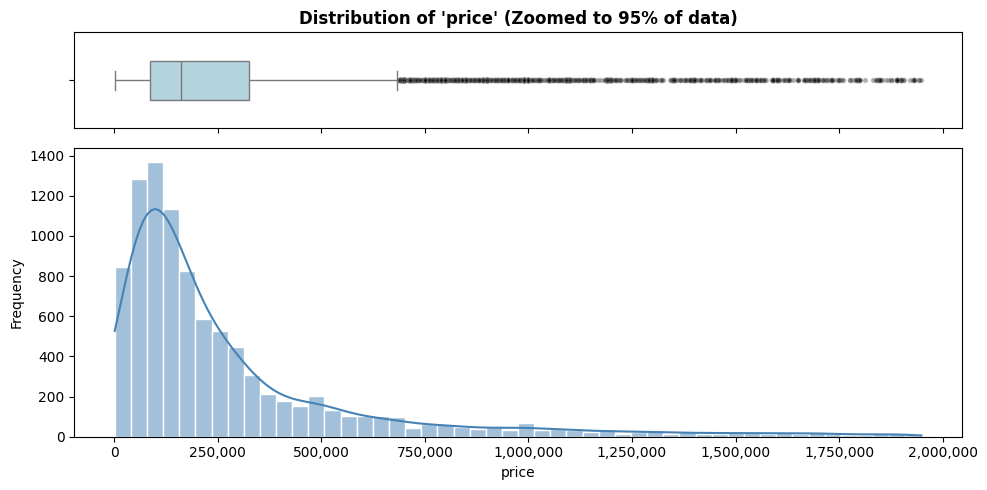

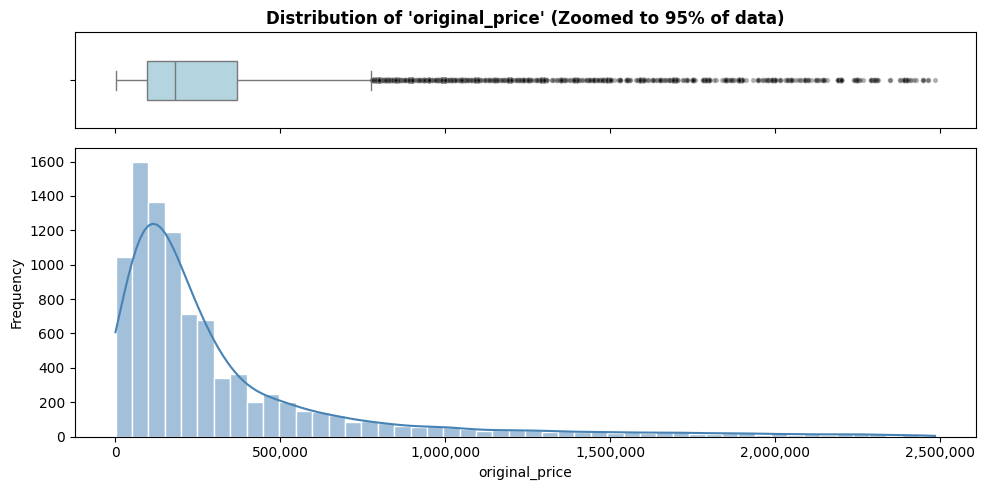

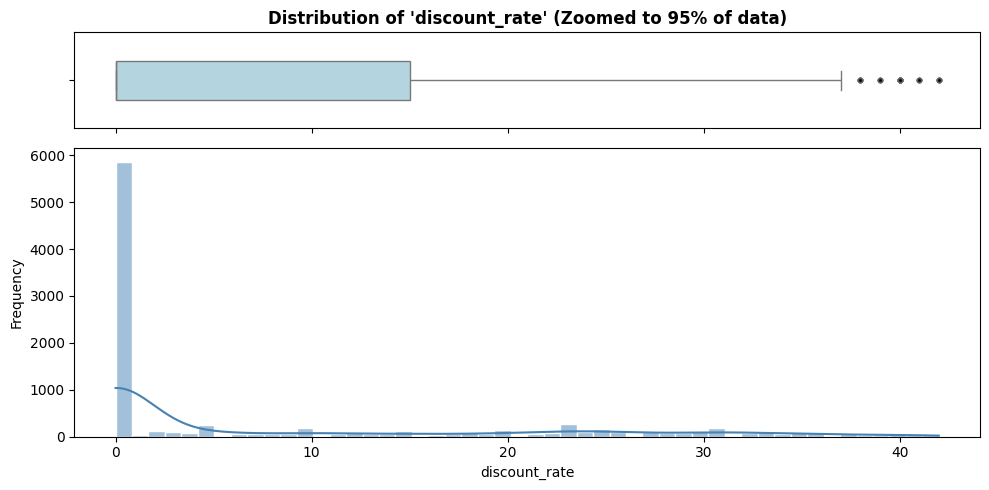

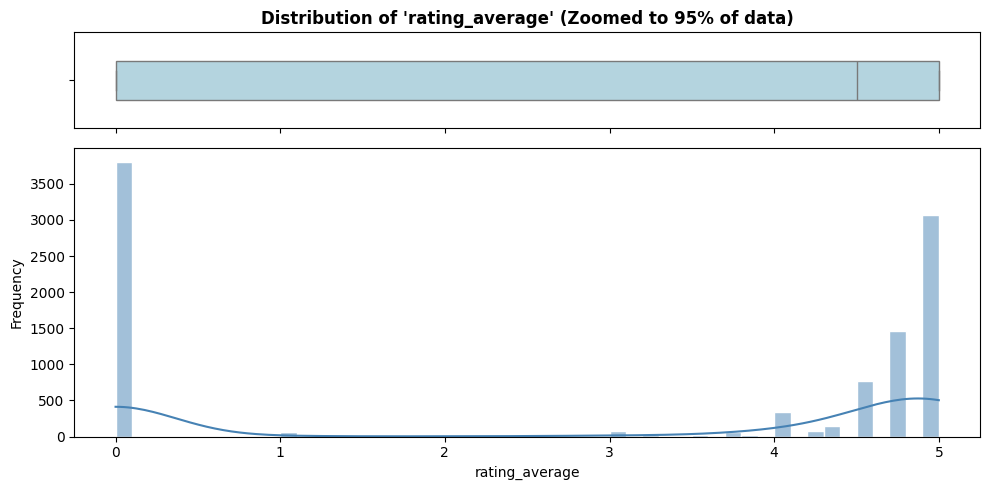

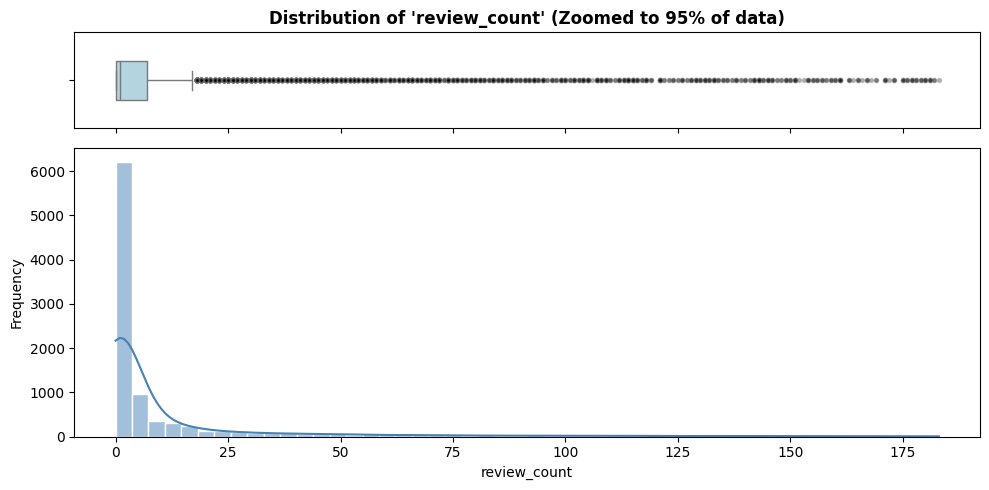

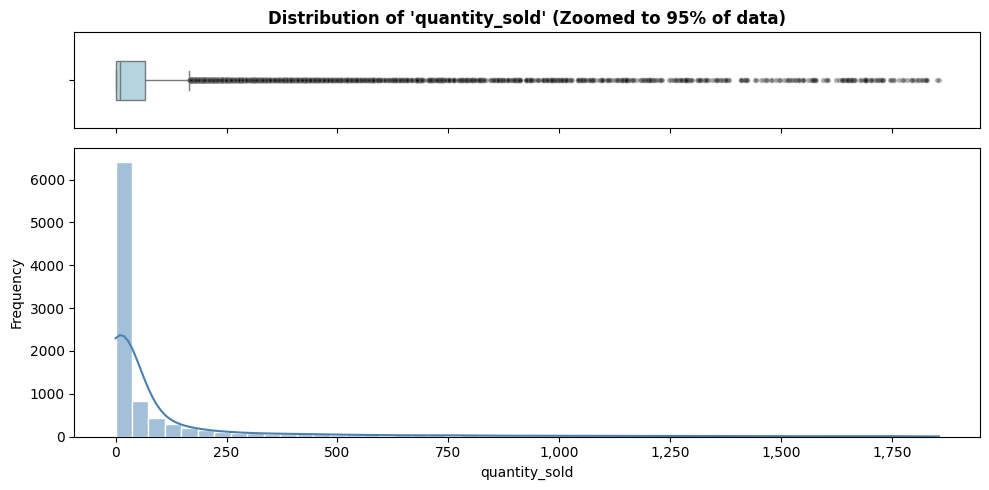

In [15]:
numeric_features_tiki = ['price', 'original_price', 'discount_rate', 'rating_average', 'review_count', 'quantity_sold']
print("\tTIKI DISTRIBUTIONS")
plot_distribution_with_zoom(
    df=df_tiki,
    columns=[c for c in numeric_features_tiki if c in df_tiki.columns],
    quantile_threshold=0.95
)

Đa số các biến mang đặc trưng phân phối lệch phải cực mạnh. Lượt bán (`quantity_sold`) và đánh giá (`review_count`) tập trung chủ yếu ở mức thấp, có một cái đuôi rất dài kéo về bên phải, đại diện cho số ít các sản phẩm "Best-seller".

	EBAY DISTRIBUTIONS


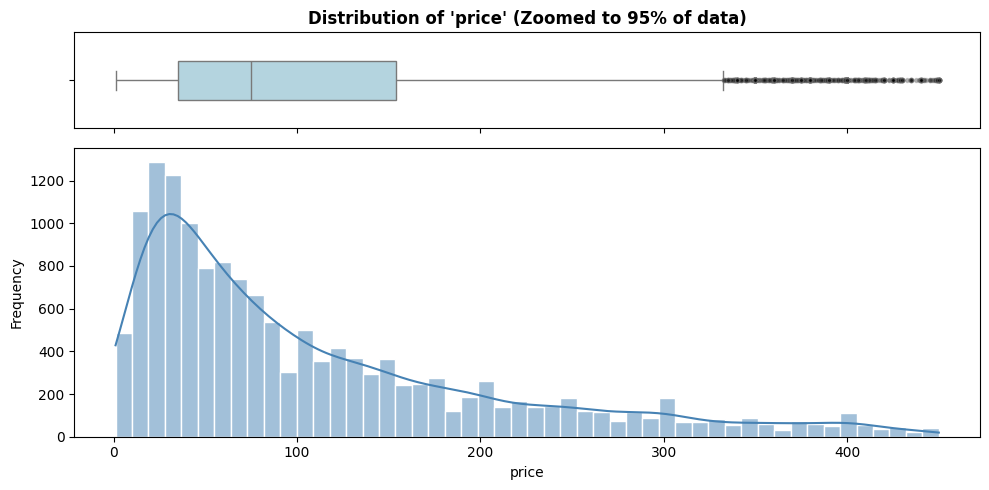

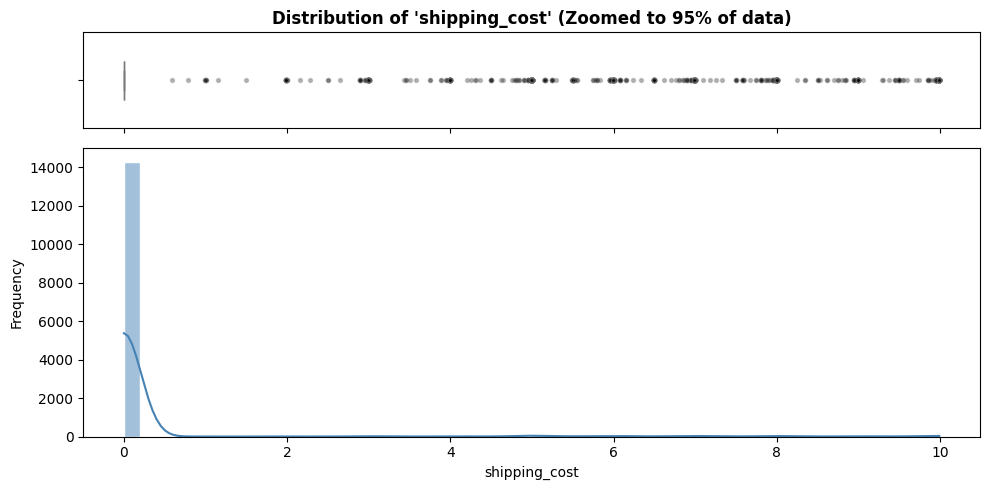

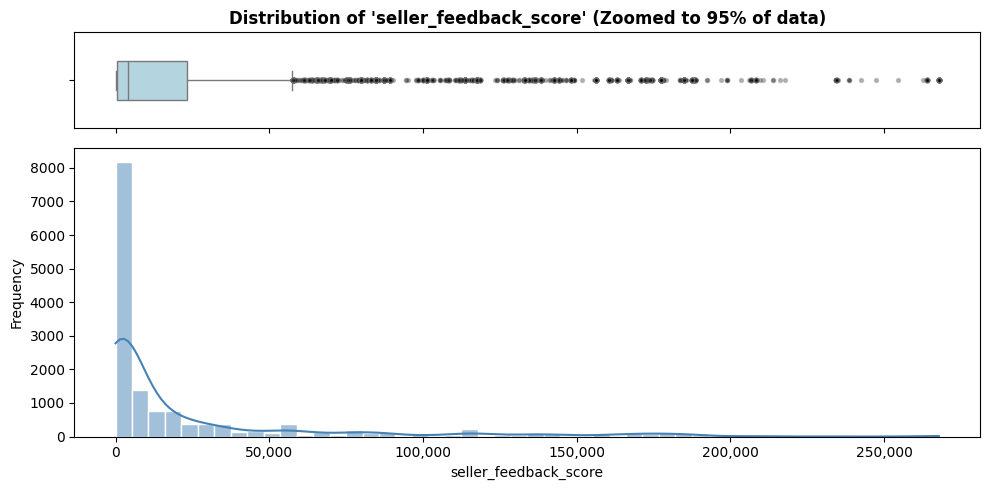

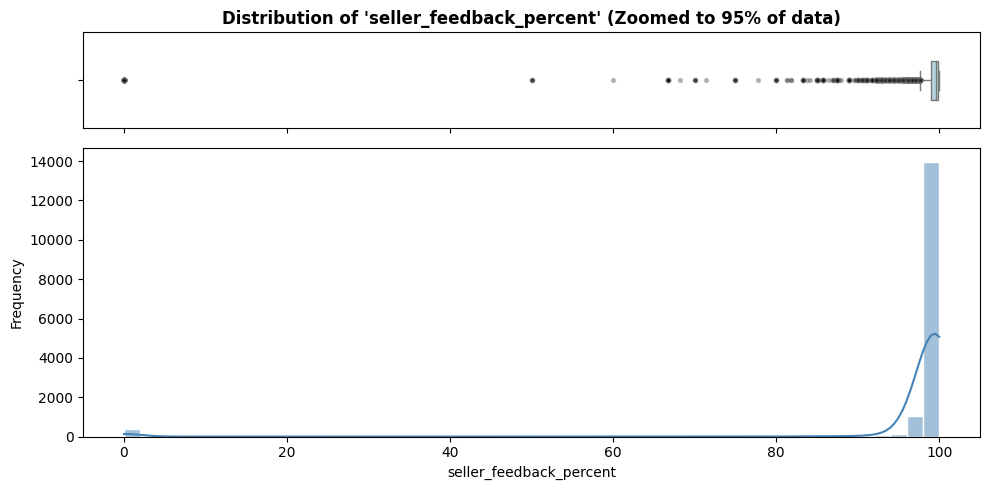

In [16]:
numeric_features_ebay = ['price', 'shipping_cost', 'seller_feedback_score', 'seller_feedback_percent']
print("\tEBAY DISTRIBUTIONS")
plot_distribution_with_zoom(
    df=df_ebay,
    columns=[c for c in numeric_features_ebay if c in df_ebay.columns],
    quantile_threshold=0.95
)

Điểm đáng chú ý nhất là biến `seller_feedback_percent`. Thay vì phân phối lệch phải như thường thấy, biến này lại lệch trái rất mạnh. Biểu đồ Histogram cho thấy một cột thẳng đứng tại mốc 100%, điều này cho thấy môi trường cạnh tranh về uy tín trên nền tảng eBay rất khốc liệt, hầu hết người bán đều cố gắng duy trì điểm phản hồi trên 98%.

### **5.2. Statistical Detection**

Để xác định chính xác ranh giới của các điểm ngoại lai bằng con số cụ thể, nhóm áp dụng phương pháp thống kê *IQR (Interquartile Range)* thay vì Z-score. Lý do là Z-score rất nhạy cảm với các giá trị cực đoan và chỉ thực sự chuẩn xác khi dữ liệu có phân phối chuẩn. Trong khi đó, dữ liệu E-commerce của chúng ta chủ yếu là phân phối lệch, do đó IQR sẽ mang lại tính bền vững cao hơn.

Công thức xác định ranh giới:
* $IQR = Q3 - Q1$
* $Lower\_Bound = Q1 - 1.5 \times IQR$
* $Upper\_Bound = Q3 + 1.5 \times IQR$

Những điểm dữ liệu nằm ngoài khoảng $[Lower\_Bound, Upper\_Bound]$ sẽ được thống kê là ngoại lai (Outliers).

In [17]:
# Assuming detect_outliers_iqr_summary is defined
outlier_summary_tiki = detect_outliers_iqr_summary(
    df=df_tiki,
    columns=[c for c in numeric_features_tiki if c in df_tiki.columns]
)
print("\tOUTLIER SUMMARY (IQR METHOD) - TIKI:")
display(outlier_summary_tiki)

	OUTLIER SUMMARY (IQR METHOD) - TIKI:


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,price,89000.0,385000.0,296000.0,-355000.0,829000.0,1214,12.14
1,original_price,99000.0,446250.0,347250.0,-421875.0,967125.0,1236,12.36
2,discount_rate,0.0,20.0,20.0,-30.0,50.0,280,2.80
3,rating_average,0.0,5.0,5.0,-7.5,12.5,0,0.00
4,review_count,0.0,10.0,10.0,-15.0,25.0,1666,16.66
5,quantity_sold,2.0,93.0,91.0,-134.5,229.5,1664,16.64


* **Tiki (Nhóm biến giá cả):** Các biến `price` và `original_price` có tỷ lệ ngoại lai khoảng *~12%*. Lower Bound mang giá trị âm là hệ quả toán học do dữ liệu bị lệch phải nặng (chứa nhiều sản phẩm giá trị thấp). Ranh giới trên (~829,000 VND) là một ngưỡng khá thấp. Nếu áp dụng xóa cứng nhắc theo IQR, toàn bộ các sản phẩm phân khúc cao cấp (trên 829k) sẽ bị loại bỏ, làm sai lệch phân tích chiến lược định giá.
* **Tiki (Nhóm biến tương tác):** Cột `quantity_sold` và `review_count` có tỷ lệ ngoại lai cao nhất (*~16.6%*). Ranh giới trên rất hẹp (lượt bán > 229). Tương tự như giá cả, đây thực chất là tín hiệu của các sản phẩm "Best-seller" – nhóm mang lại doanh thu chủ lực, tuyệt đối không được coi là dữ liệu lỗi cần xóa.
* **Tiki (Nhóm biến tỷ lệ):** `discount_rate` có *2.8%* ngoại lai (mức giảm > 50%), đại diện cho các chiến dịch Flash Sale sâu hoặc chiến lược đẩy hàng tồn kho.

In [18]:
outlier_summary_ebay = detect_outliers_iqr_summary(
    df=df_ebay,
    columns=[c for c in numeric_features_ebay if c in df_ebay.columns]
)
print("\tOUTLIER SUMMARY (IQR METHOD) - EBAY:")
display(outlier_summary_ebay)

	OUTLIER SUMMARY (IQR METHOD) - EBAY:


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,price,35.33,175.0,139.67,-174.175,384.505,1162,7.38
1,shipping_cost,0.00,0.0,0.00,0.000,0.000,1484,9.43
2,seller_feedback_score,601.00,31736.0,31135.00,-46101.500,78438.500,2425,15.40
3,seller_feedback_percent,99.00,99.9,0.90,97.650,101.250,1464,9.30


* **eBay (Biến uy tín):** Cột `seller_feedback_percent` có *9.3%* dữ liệu nằm ngoài khoảng ranh giới hẹp (97.65% - 101.25%). Điều này chứng minh mức độ cạnh tranh uy tín cực kỳ khốc liệt trên eBay, nơi một người bán có feedback dưới 97% đã có thể bị coi là một "điểm bất thường" so với cộng đồng.
* **eBay (Nhóm biến tài chính):** Tỷ lệ ngoại lai của `shipping_cost` lên tới *9.43%*, trong đó IQR tính toán ranh giới là 0$. Điều này cho thấy chiến lược Freeship (phí vận chuyển = 0) là tiêu chuẩn áp đảo trên nền tảng này, các đơn hàng thu phí ship trở thành thiểu số bị gắn mác ngoại lai. Cột `price` có tỷ lệ ngoại lai *27.38%* với ranh giới trên chỉ ở mức 384.5 USD, cho thấy sự chênh lệch lớn giữa các mặt hàng giá rẻ và các sản phẩm công nghệ cao cấp (như Laptop) trên sàn.

### **5.3. Outlier Handling**

Việc sử dụng các mô hình học máy như Isolation Forest để phát hiện ngoại lai nhiều biến là một kỹ thuật mạnh mẽ. Tuy nhiên, nếu áp dụng mù quáng để *xóa (drop)* dữ liệu dựa trên các biến như `quantity_sold` hay `seller_feedback_score`, nhóm sẽ vô tình loại bỏ nhóm sản phẩm bán chạy nhất và các nhà bán hàng uy tín nhất – vốn là trọng tâm phân tích của một nền tảng E-commerce.

Do đó, nhóm quyết định không xóa dữ liệu, mà áp dụng chiến lược *Winsorization (Capping)* tại bách phân vị thứ 99 (99th Percentile). Kỹ thuật này chỉ "cắt ngọn" 1% các giá trị tài chính cao vô lý (do lỗi thiết lập giá/vận chuyển), đồng thời *bảo toàn nguyên vẹn* các chỉ số tương tác kinh doanh lõi.

In [19]:
print(f"Original records - Tiki: {df_tiki.shape[0]}, Ebay: {df_ebay.shape[0]}")

# 1. Tiki Capping: Apply ONLY to financial metrics
financial_cols_tiki = ['price', 'original_price']
df_tiki_clean = cap_outliers_percentile(df_tiki, financial_cols_tiki, upper_percentile=0.99)

# 2. Ebay Capping: Apply ONLY to price and shipping cost
financial_cols_ebay = ['price', 'shipping_cost']
df_ebay_clean = cap_outliers_percentile(df_ebay, financial_cols_ebay, upper_percentile=0.99)

print(f"Cleaned records  - Tiki: {df_tiki_clean.shape[0]}, Ebay: {df_ebay_clean.shape[0]}")
print("Note: 100% of rows are preserved. Outliers in financial columns were safely capped at the 99th percentile.")

Original records - Tiki: 10000, Ebay: 15744
Cleaned records  - Tiki: 10000, Ebay: 15744
Note: 100% of rows are preserved. Outliers in financial columns were safely capped at the 99th percentile.


## **6. Feature Engineering & Data Transformation**

Để đáp ứng chính xác các mục tiêu phân tích kinh doanh và chuẩn bị dữ liệu đầu vào cho Interactive Dashboard, nhóm tiến hành tạo các đặc trưng mới. Việc chuyển đổi các biến định lượng thô thành các nhóm phân khúc (Categorical segments) hoặc quy đổi tỷ giá sẽ giúp quá trình trực quan hóa (như vẽ Boxplot, Bar Chart) trở nên trực quan và mang lại nhiều thông tin hữu ích hơn.

### **6.1. Feature Engineering for Tiki Dataset**

Đối với nền tảng Tiki, nhóm tập trung tạo các biến phân khúc dựa trên hành vi giảm giá và hiệu suất bán hàng:
* **`Discount_Segment`:** Phân rã biến `discount_rate` thành các nhóm rời rạc: "0%", "< 20%", "20-50%", và "> 50%". Biến này giúp đánh giá xem mức độ khuyến mãi sâu có thực sự thúc đẩy doanh số hay không.
* **`Is_Best_Seller`:** Biến nhị phân (Binary feature: 1/0) dựa trên `quantity_sold` (ngưỡng > 100 lượt bán được coi là 1). Biến này đóng vai trò nhãn (label) để phân biệt các sản phẩm "ngôi sao" với phần còn lại của gian hàng.

In [20]:
print("\tTIKI: Feature Engineering Status ---")
df_tiki_clean = engineer_tiki_features(df_tiki_clean)
display(df_tiki_clean[['price', 'discount_rate', 'quantity_sold', 'Discount_Segment', 'Is_Best_Seller']].head())

	TIKI: Feature Engineering Status ---


,price,discount_rate,quantity_sold,Discount_Segment,Is_Best_Seller
0,320000.0,0,0,0%,0
1,610000.0,0,0,0%,0
2,509000.0,0,51,0%,0
3,45000.0,10,49,< 20%,0
4,69000.0,0,21,0%,0


### 6.2. **Feature Engineering for eBay Dataset**

Đối với nền tảng eBay, nhóm tập trung vào việc chuẩn hóa chi phí để so sánh chéo nền tảng và phân loại mức độ uy tín của người bán:
* **`Total_Cost_VND`:** Tạo biến tổng chi phí (Giá sản phẩm + Phí vận chuyển) và quy đổi từ USD sang VND (tạm tính tỷ giá: 26,000 VND/USD). Biến này bắt buộc phải có để đồng bộ thang đo khi đặt eBay và Tiki lên cùng một Dashboard.
* **`Listing_Duration_Days`:** Tính vòng đời bài đăng bằng cách lấy `item_end_date` trừ đi `item_creation_date`. Dù biến `item_end_date` có tỷ lệ khuyết lớn, nhóm vẫn tạo đặc trưng này cho các bản ghi hợp lệ để phục vụ các phân tích đặc thù (nếu có).
* **`Trust_Level`:** Phân loại `seller_feedback_percent` thành "High Trust" (>98%) và "Normal/Low Trust" (<=98%). Biến này rất quan trọng để kiểm định giả thuyết: *"Người bán uy tín cao có xu hướng định giá sản phẩm cao hơn hay không?"*.

In [21]:
print("\tEBAY: Feature Engineering Status ---")
df_ebay_clean = engineer_ebay_features(df_ebay_clean)
display(df_ebay_clean[['price', 'shipping_cost', 'seller_feedback_percent', 'Total_Cost_VND', 'Trust_Level']].head())

	EBAY: Feature Engineering Status ---


,price,shipping_cost,seller_feedback_percent,Total_Cost_VND,Trust_Level
0,371.99,0.0,99.0,9299750.0,High Trust
1,146.11,0.0,99.3,3652750.0,High Trust
2,254.75,0.0,99.3,6368750.0,High Trust
3,899.99,0.0,99.0,22499750.0,High Trust
4,329.99,0.0,98.6,8249750.0,High Trust


Kết quả hiển thị từ các bảng (DataFrames) cho thấy các biến mới đã được tính toán và gán nhãn thành công.
* **Trên tập Tiki:** Biến `Discount_Segment` đã phân loại chuẩn xác các mức giảm giá (ví dụ: sản phẩm không giảm giá được gán nhãn "0%", sản phẩm giảm 10% nằm trong nhóm "< 20%").
* **Trên tập eBay:** Biến `Total_Cost_VND` đã cộng gộp thành công giá bán và phí vận chuyển, sau đó quy đổi sang tiền Việt với giá trị lên tới hàng triệu đồng (VD: 371.99 USD tương đương ~9.3 triệu VND). Biến `Trust_Level` cũng hoạt động đúng logic khi gán nhãn "High Trust" cho các tài khoản có tỷ lệ phản hồi trên 98%. 

Việc chuyển đổi thành công các đặc trưng này giúp bộ dữ liệu hiện tại hoàn toàn sẵn sàng để được nạp vào Streamlit xây dựng Interactive Dashboard.

## **7. Data Structuring & Relational Modeling (Database Normalization)**

Để tối ưu hóa hiệu suất cho Interactive Dashboard và phục vụ các truy vấn phức tạp, nhóm tiến hành tái cấu trúc hai tập dữ liệu phẳng ban đầu thành một mô hình cơ sở dữ liệu quan hệ. 

Quy trình này áp dụng kỹ thuật chuẩn hóa dữ liệu, chia tách thông tin thành 5 bảng cốt lõi theo kiến trúc Star Schema (Mô hình sao):
1. **`Dim_Category` (Bảng danh mục):** Lưu trữ danh mục duy nhất của cả hai sàn, cung cấp `category_id` chuẩn hóa.
2. **`Dim_Product` (Bảng sản phẩm):** Lưu trữ thông tin định danh tĩnh của sản phẩm (Tên, Thương hiệu, Nền tảng) và liên kết với `Dim_Category` qua khóa ngoại `category_id`.
3. **`Dim_Seller` (Bảng người bán):** Cung cấp hồ sơ uy tín của người bán trên eBay (Khóa chính: `seller_username`).
4. **`Fact_Listings_Tiki` (Bảng sự kiện - Tiki):** Lưu trữ các chỉ số đo lường thay đổi theo thời gian như giá cả, lượt bán, đánh giá.
5. **`Fact_Listings_Ebay` (Bảng sự kiện - eBay):** Lưu trữ các chỉ số tài chính, phí vận chuyển và vòng đời bài đăng.

Việc phân tách này giúp loại bỏ hoàn toàn sự dư thừa dữ liệu và tránh các lỗi bất thường khi cập nhật.

In [22]:
# Table 1: Dim_Category
# Extract unique categories from both datasets
cat_tiki = df_tiki_clean[['category']].dropna()
cat_ebay = df_ebay_clean[['category_path']].rename(columns={'category_path': 'category'}).dropna()

all_categories = pd.concat([cat_tiki, cat_ebay]).drop_duplicates().reset_index(drop=True)
dim_category = all_categories.copy()
# Generate unique surrogate keys for categories (e.g., CAT_0001)
dim_category['category_id'] = ['CAT_' + str(i+1).zfill(4) for i in range(len(dim_category))]
print(f"Dim_Category shape: {dim_category.shape}")

Dim_Category shape: (694, 2)


In [23]:
# Table 2: Dim_Product
# Extract Tiki products
dim_prod_tiki = df_tiki_clean[['id', 'name', 'brand', 'category']].copy()
dim_prod_tiki.rename(columns={'id': 'product_id', 'name': 'product_name'}, inplace=True)
dim_prod_tiki['platform'] = 'Tiki'

# Extract Ebay products
dim_prod_ebay = df_ebay_clean[['item_id', 'title', 'category_path']].copy()
dim_prod_ebay.rename(columns={'item_id': 'product_id', 'title': 'product_name', 'category_path': 'category'}, inplace=True)
dim_prod_ebay['brand'] = 'Unknown' # Ebay dataset lacks explicit brand column
dim_prod_ebay['platform'] = 'Ebay'

# Combine and deduplicate
dim_product = pd.concat([dim_prod_tiki, dim_prod_ebay], ignore_index=True)
dim_product = dim_product.drop_duplicates(subset=['product_id', 'platform'])

# Normalization: Merge category_id and drop the redundant category string column
dim_product = dim_product.merge(dim_category, on='category', how='left')
dim_product.drop(columns=['category'], inplace=True)
print(f"Dim_Product shape: {dim_product.shape}")

Dim_Product shape: (25744, 5)


In [24]:
# Table 3: Dim_Seller (Ebay Only)
seller_cols = ['seller_username', 'seller_feedback_score', 'seller_feedback_percent', 'Trust_Level']
valid_seller_cols = [c for c in seller_cols if c in df_ebay_clean.columns]

dim_seller = df_ebay_clean[valid_seller_cols].copy()
dim_seller = dim_seller.drop_duplicates(subset=['seller_username']).reset_index(drop=True)
print(f"Dim_Seller shape: {dim_seller.shape}")

Dim_Seller shape: (6858, 4)


In [25]:
# Table 4: Fact_Listings_Tiki
# Snapshot values representing price points, reviews and engineered features
tiki_fact_cols = ['id', 'price', 'original_price', 'discount_rate', 'rating_average', 'review_count', 'quantity_sold', 'Discount_Segment', 'Is_Best_Seller']
valid_tiki_cols = [c for c in tiki_fact_cols if c in df_tiki_clean.columns]

fact_tiki = df_tiki_clean[valid_tiki_cols].copy()
fact_tiki.rename(columns={'id': 'product_id'}, inplace=True)
print(f"Fact_Listings_Tiki shape: {fact_tiki.shape}")

Fact_Listings_Tiki shape: (10000, 9)


In [26]:
# Table 5: Fact_Listings_Ebay
# Financial and shipping metrics along with seller mapping
ebay_fact_cols = ['item_id', 'seller_username', 'price', 'shipping_cost', 'Total_Cost_VND', 'condition', 'item_creation_date', 'Listing_Duration_Days']
valid_ebay_cols = [c for c in ebay_fact_cols if c in df_ebay_clean.columns]

fact_ebay = df_ebay_clean[valid_ebay_cols].copy()
fact_ebay.rename(columns={'item_id': 'product_id'}, inplace=True)
print(f"Fact_Listings_Ebay shape: {fact_ebay.shape}")

Fact_Listings_Ebay shape: (15744, 7)


Quá trình chia tách dữ liệu đã diễn ra thành công, tạo lập nên một cấu trúc CSDL cực kỳ chặt chẽ:
* **Normalization:** Bảng `Dim_Category` (694 danh mục duy nhất) đã được sinh khóa `category_id` và nhúng thành công vào bảng `Dim_Product` (~25.7k sản phẩm). Việc loại bỏ chuỗi văn bản danh mục dài dòng khỏi bảng sản phẩm giúp tiết kiệm không gian bộ nhớ và tăng tốc độ lọc trên Dashboard.
* **Key Mapping:** Các bảng `Fact_Listings` giờ đây hoàn toàn đóng vai trò là bảng chứa các con số đo lường và khóa ngoại (Foreign Keys như `product_id`, `seller_username`). Chúng ta đã tách bạch rõ ràng giữa "đặc tính tĩnh" (Dimension) và "chỉ số động" (Fact).

## **8. Data Export & Pipeline Finalization**

Giai đoạn cuối cùng của quy trình tiền xử lý là trích xuất các bảng dữ liệu đã được làm sạch và chuẩn hóa . 

Năm bảng dữ liệu thuộc mô hình Relational Schema này đóng vai trò là "Single Source of Truth". Chúng sẽ được lưu trữ dưới định dạng `.csv` tại thư mục `data/processed/`, sẵn sàng đóng vai trò là cơ sở dữ liệu đầu vào cho việc xây dựng Interactive Dashboard bằng thư viện Streamlit ở giai đoạn tiếp theo.

In [27]:
# Define the output directory for processed data
PROCESSED_DIR = "../data/processed"

# Create the directory if it does not exist
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Export the 5 structured tables to CSV format without the index column
dim_product.to_csv(os.path.join(PROCESSED_DIR, "dim_product.csv"), index=False)
dim_seller.to_csv(os.path.join(PROCESSED_DIR, "dim_seller.csv"), index=False)
dim_category.to_csv(os.path.join(PROCESSED_DIR, "dim_category.csv"), index=False)
fact_tiki.to_csv(os.path.join(PROCESSED_DIR, "fact_tiki_listings.csv"), index=False)
fact_ebay.to_csv(os.path.join(PROCESSED_DIR, "fact_ebay_listings.csv"), index=False)

print(f"Target Directory: '{PROCESSED_DIR}'")
print("Successfully exported the following files:")

# Loop through the directory and print file names with their sizes in MB
for file in sorted(os.listdir(PROCESSED_DIR)):
    if file.endswith('.csv'):
        filepath = os.path.join(PROCESSED_DIR, file)
        filesize_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f" - {file:<25} | Size: {filesize_mb:.2f} MB")
print("\n[PIPELINE COMPLETE] The dataset is now ready for Dashboard Integration.")

Target Directory: '../data/processed'
Successfully exported the following files:
 - dim_category.csv          | Size: 0.02 MB
 - dim_product.csv           | Size: 2.91 MB
 - dim_seller.csv            | Size: 0.22 MB
 - fact_ebay_listings.csv    | Size: 1.32 MB
 - fact_tiki_listings.csv    | Size: 0.41 MB

[PIPELINE COMPLETE] The dataset is now ready for Dashboard Integration.


Hệ thống đã ghi nhận việc xuất thành công 5 tập tin CSV. Việc kiểm tra dung lượng (size) cho thấy các file có kích thước rất tối ưu (chỉ từ vài chục KB đến vài MB), đảm bảo Interactive Dashboard khi tải các file này lên bộ nhớ (RAM) sẽ hoạt động mượt mà, không xảy ra hiện tượng tràn bộ nhớ hay giật lag khi người dùng thao tác với các bộ lọc.

Quy trình ETL (Extract, Transform, Load) nội bộ của đồ án đến đây là hoàn tất. Nhóm đã sẵn sàng chuyển sang bước phân tích trực quan hóa trên giao diện người dùng.

---